In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pprint

import hydra
from omegaconf import OmegaConf
import numpy as np
import torch
import lightning.pytorch as ptl
import polars as pl
import pandas as pd
import altair as alt
alt.data_transformers.enable("vegafusion")
import seaborn as sns

import conf.conf
import rna_vel_pred.callbacks
import rna_vel_pred.datasets
import rna_vel_pred.main as main_module
import rna_vel_pred.models
import rna_vel_pred.utils

/home/ttransue/GitHub/velocityPrediction/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /home/ttransue/GitHub/velocityPrediction/.venv/lib/python3.10/site-packages/libpyg.so: undefined symbol: _ZN5torch8autograd12VariableInfoC1ERKN2at6TensorE
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/home/ttransue/GitHub/velocityPrediction/.venv/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/ttransue/GitHub/velocityPrediction/.venv/lib/python3.10/site-packages/torch_scatter/_scatter_cuda.so: undefined symbol: _ZN2at4_ops16div__Tensor_mode4callERNS_6TensorERKS2_St8optionalIN3c1017basic_string_viewIcEEE
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/ttransue/GitHub/velocityPrediction/.venv/lib/python3.10/site-packages/torch_geometr

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

In [4]:
db = conf.conf.Session()
db.begin()

In [5]:
with hydra.initialize(version_base=None, config_path='../conf'):
    cfg = hydra.compose(config_name='conf', overrides=[
        'model=Second',
        'datasets=['
            '{_target_:conf.datasets.H5adUMap,dataset:BONEMARROW,umap_dimension:2,time_step_count_sparsify:50,neighbor_count:110}'
            # ','
            # '{_target_:conf.datasets.H5adUMap,dataset:FOREBRAIN,umap_dimension:2,reverse_velocities:true,time_step_count_sparsify:141,neighbor_count:130}'
        ']'
        ,
    ])
    cfg = conf.conf.orm.instantiate_and_insert_config(db, OmegaConf.to_container(cfg, resolve=True))
    pprint.pp(cfg)

Conf(root_dir='/home/ttransue/GitHub/velocityPrediction',
     out_dir='/home/ttransue/out/rna_vel_pred',
     data_subdir='/home/ttransue/out/rna_vel_pred/data_redesign',
     run_subdir='runs',
     prediction_filename='prediction.parquet',
     device='cuda',
     alt_id='rtm06kqa',
     rng_seed=2376999025,
     fit=True,
     predict=False,
     is_optuna_sweep=False,
     id=2103,
     datasets=[H5adUMap(time_step_count_sparsify=50,
                        neighbor_count=110,
                        frac_train=0.7,
                        frac_val=0.2,
                        frac_test=0.1,
                        batch_size=10,
                        limit_batch_count_train=False,
                        batch_count_train=10,
                        reverse_velocities=False,
                        id=931,
                        dataset=<UMapDataset.BONEMARROW: 'BONEMARROW'>,
                        processed_filename='y2hhr6s7',
                        umap_dimension=2)],
   

In [6]:
splits = rna_vel_pred.datasets.get_merged_dataset(cfg, cfg.data_dir, rng_seed=cfg.rng_seed)

Seed set to 2376999025
Seed set to 2376999025


In [597]:
model, ckpt_path = rna_vel_pred.models.get_model(cfg.model, rng_seed=cfg.rng_seed)
lightning = main_module.Lightning(cfg, splits, model)

Seed set to 2376999025


<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.linear.Linear'>
<class 'torch_geometric.nn.dense.linear.Linear'>


In [598]:
save_loss = rna_vel_pred.callbacks.SaveLoss()
activation_stats = rna_vel_pred.callbacks.ActivationStats()
gradient_stats = rna_vel_pred.callbacks.GradientStats(max=1e-2)
colorful_dimension = rna_vel_pred.callbacks.ColorfulDimension(bins=40)
callbacks = [
    # rna_vel_pred.callbacks.LSUV(),
    # rna_vel_pred.callbacks.EMAWeightAveraging(),
    save_loss,
    activation_stats,
    gradient_stats,
    colorful_dimension,
]
trainer = ptl.Trainer(
    enable_checkpointing=False,
    devices=1,
    accelerator=cfg.device,
    max_steps=300,
    # limit_val_batches=0,
    deterministic=True,
    callbacks=callbacks,
    logger=False,
    num_sanity_val_steps=0,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [599]:
# tuner = ptl.tuner.Tuner(trainer)
# lr_finder = tuner.lr_find(model, datamodule=dataset, num_training=100, min_lr=5e-3, max_lr=1)
# fig = lr_finder.plot(suggest=True)

In [600]:
trainer.fit(lightning, ckpt_path=ckpt_path)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name  | Type   | Params | Mode 
-----------------------------------------
0 | model | Second | 10.0 K | train
-----------------------------------------
10.0 K    Trainable params
0         Non-trainable params
10.0 K    Total params
0.040     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode


Training: |                                                                                                   …

`Trainer.fit` stopped: `max_steps=300` reached.


In [601]:
def get_cmap_bounds(ts, p=.05):
    v_min, v_max = None, None
    for data in ts:
        if v_min is None:
            v_min, v_max = [None] * len(data), [None] * len(data)
        for c, channel_data in enumerate(data):
            _v_min = np.quantile(channel_data, p)
            _v_max = np.quantile(channel_data, 1 - p)
            if v_min[c] is None or v_min[c] > _v_min:
                v_min[c] = _v_min
            if v_max[c] is None or v_max[c] < _v_max:
                v_max[c] = _v_max
    return v_min, v_max

In [602]:
losses = pl.Series(save_loss.losses).to_frame('loss').with_columns(step=pl.int_range(pl.len()))
(
    alt.Chart(losses)
    .mark_line()
    .encode(
        x='step',
        y='loss',
    )
)

alt.Chart(...)

In [603]:
stats = pl.from_dicts(activation_stats.stats)#.filter(pl.col('step') < 3)
(
    alt.Chart(stats)
    .mark_line()
    .encode(
        x='step',
        y=alt.Y('value'),
        color='layer',
        # color='layer:O',
    )
    .facet(
        column='stat',
    )
    .resolve_scale(
        y='independent',
    )
)

alt.FacetChart(...)

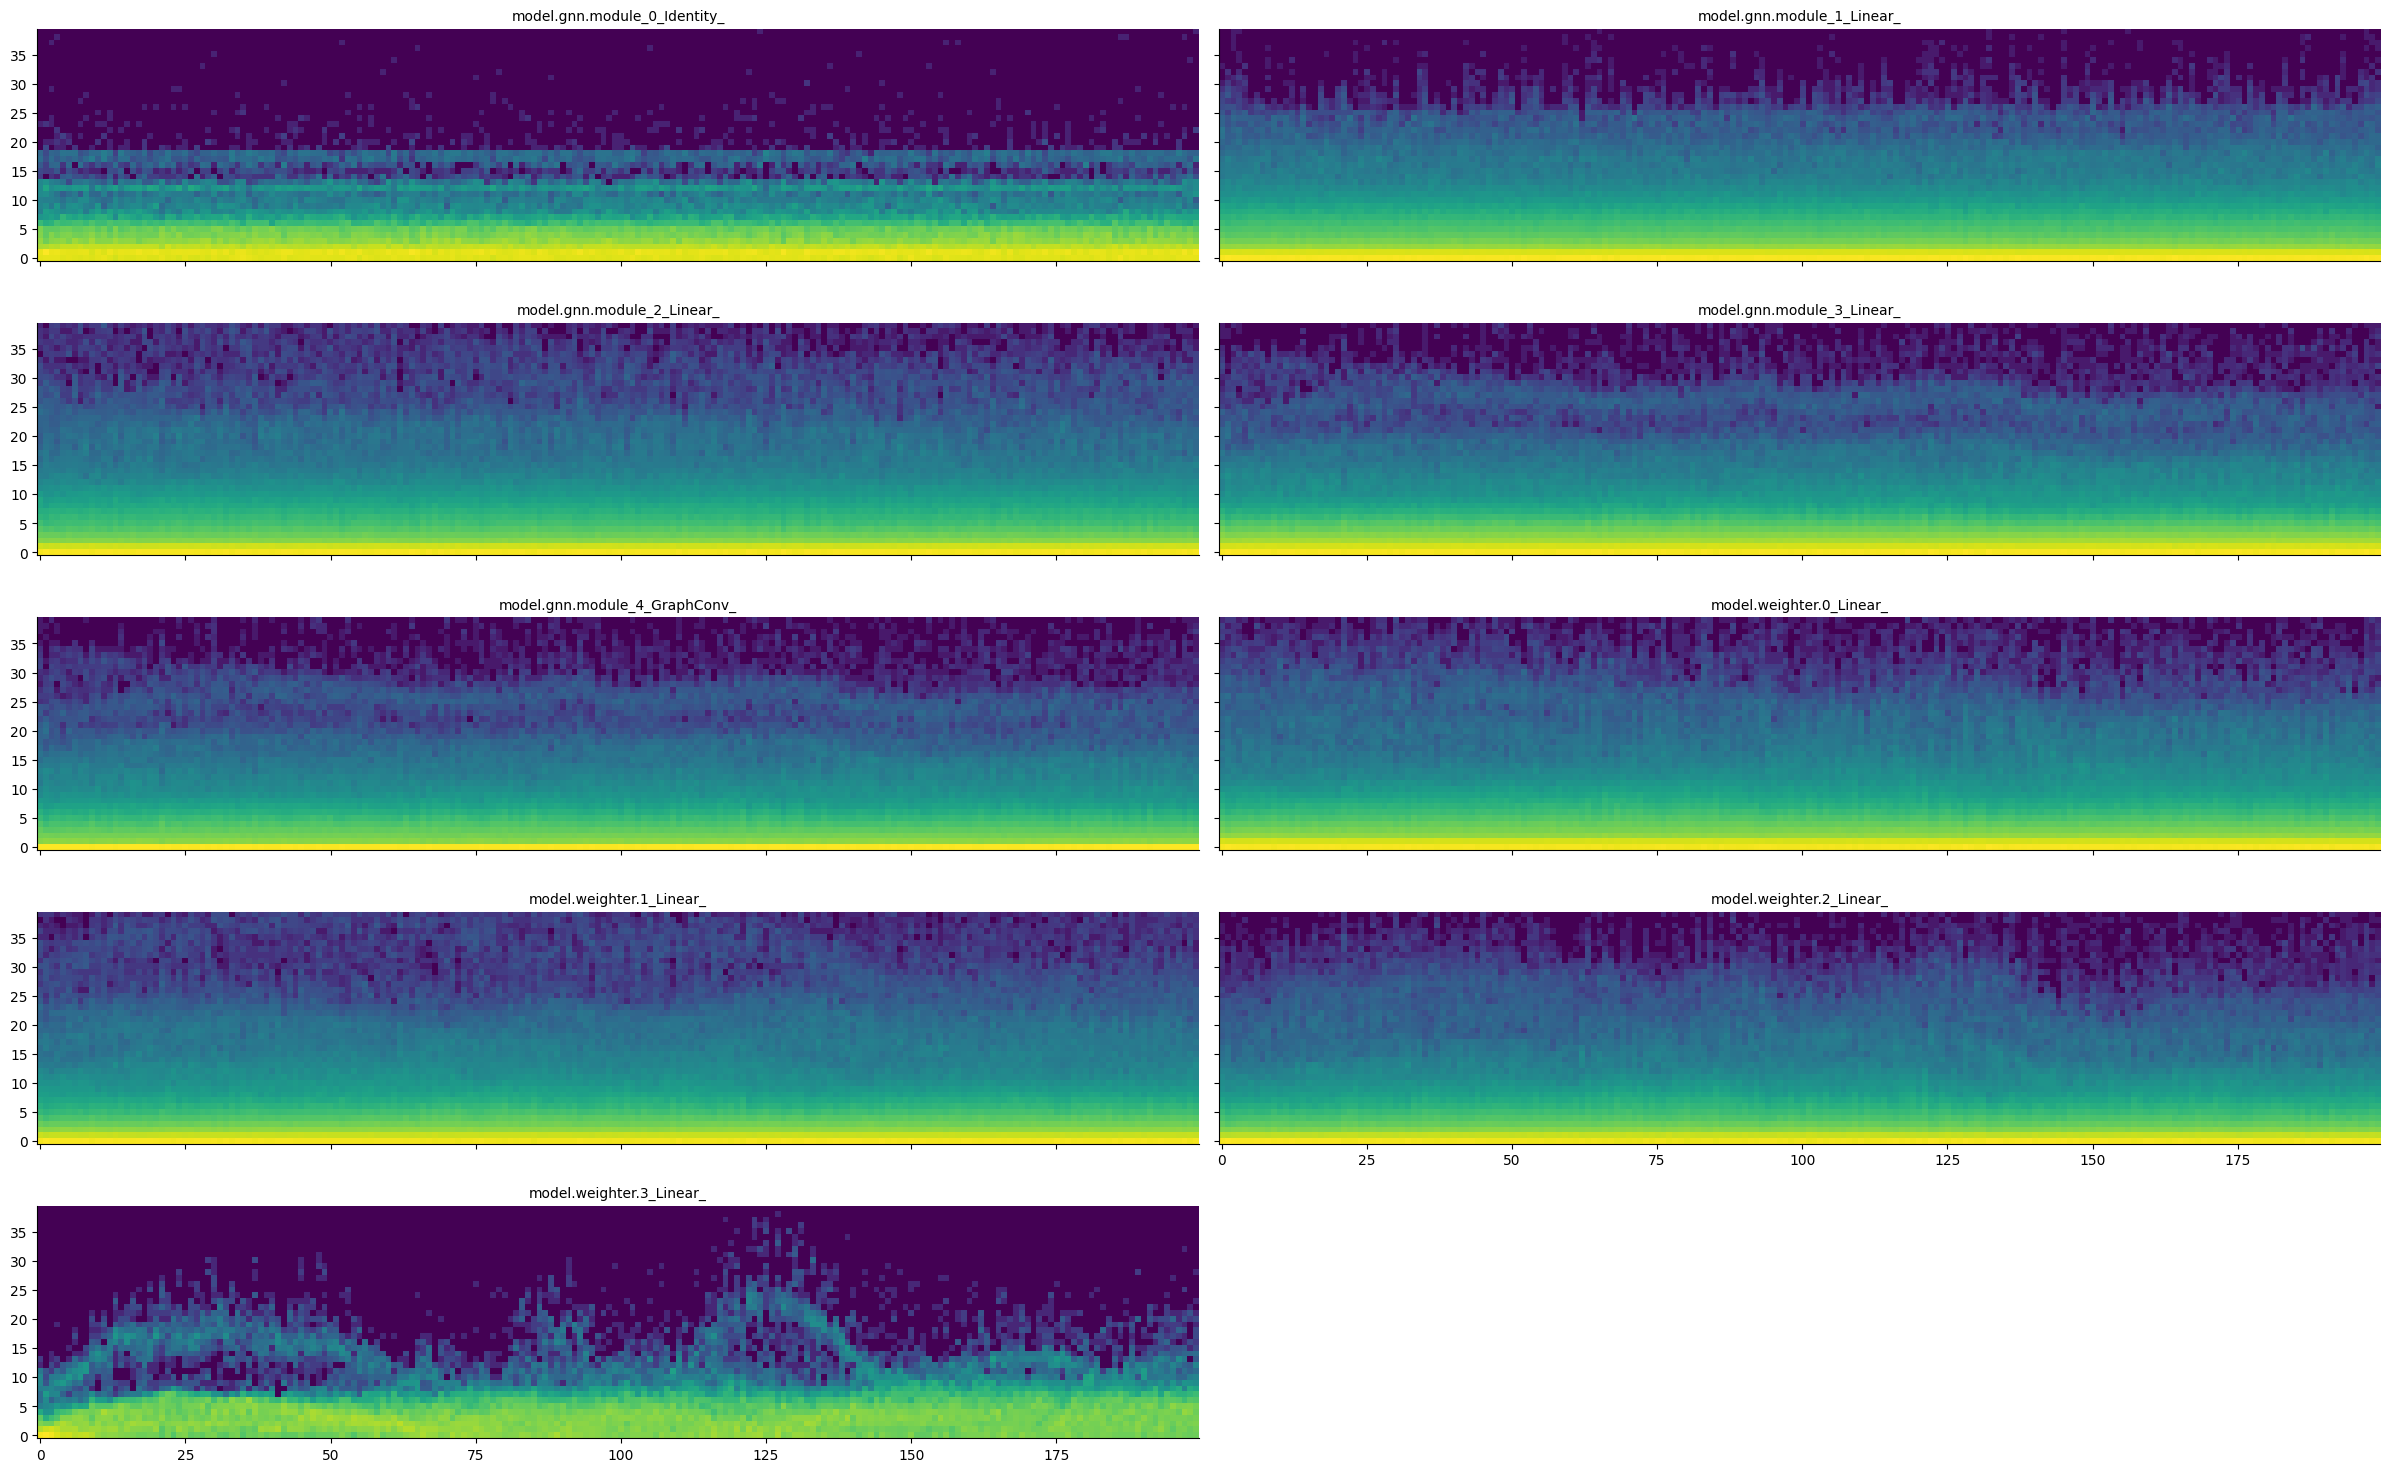

In [604]:
histograms = {}
for layer, hist in colorful_dimension.histograms.items():
    hist = torch.stack(hist).mT.numpy()
    histograms[layer] = hist
g = (
    sns.FacetGrid(
        data=pd.DataFrame({k: [0] for k in histograms}).melt(var_name='layer', value_name='value'),
        # height=10,
        aspect=4,
        col='layer',
        col_wrap=2,
        # col='value',
    )
    .set_titles('{col_name}')
)
max_evals = 200
for (_, col, hue), _ in g.facet_data():
    ax = g.axes[col]
    # ax.set_axis_off()
    layer = g.col_names[col]
    im_out = ax.imshow(np.log1p(histograms[layer][:, :max_evals]), cmap='viridis', origin='lower', aspect='equal')#, vmin=-v_absmax, vmax=v_absmax)
g.tight_layout()

In [605]:
dead = {}
for layer, hist in histograms.items():
    if 'GraphConv' not in layer:
        dead[layer] = hist[:1].sum(0) / hist.sum(0)

In [606]:
(
    alt.Chart(pl.DataFrame(dead).with_columns(step=pl.int_range(pl.len())).unpivot(index='step', variable_name='layer'))
    .mark_line()
    .encode(x='step', y='value', color='layer')
)

alt.Chart(...)

In [17]:
stats = pl.from_dicts(gradient_stats.stats)
(
    alt.Chart(stats)
    .mark_line()
    .encode(
        x='step',
        y=alt.Y('value'),
        color='layer',
    )
    .facet(
        column='stat',
    )
    .resolve_scale(
        y='independent',
    )
)

alt.FacetChart(...)

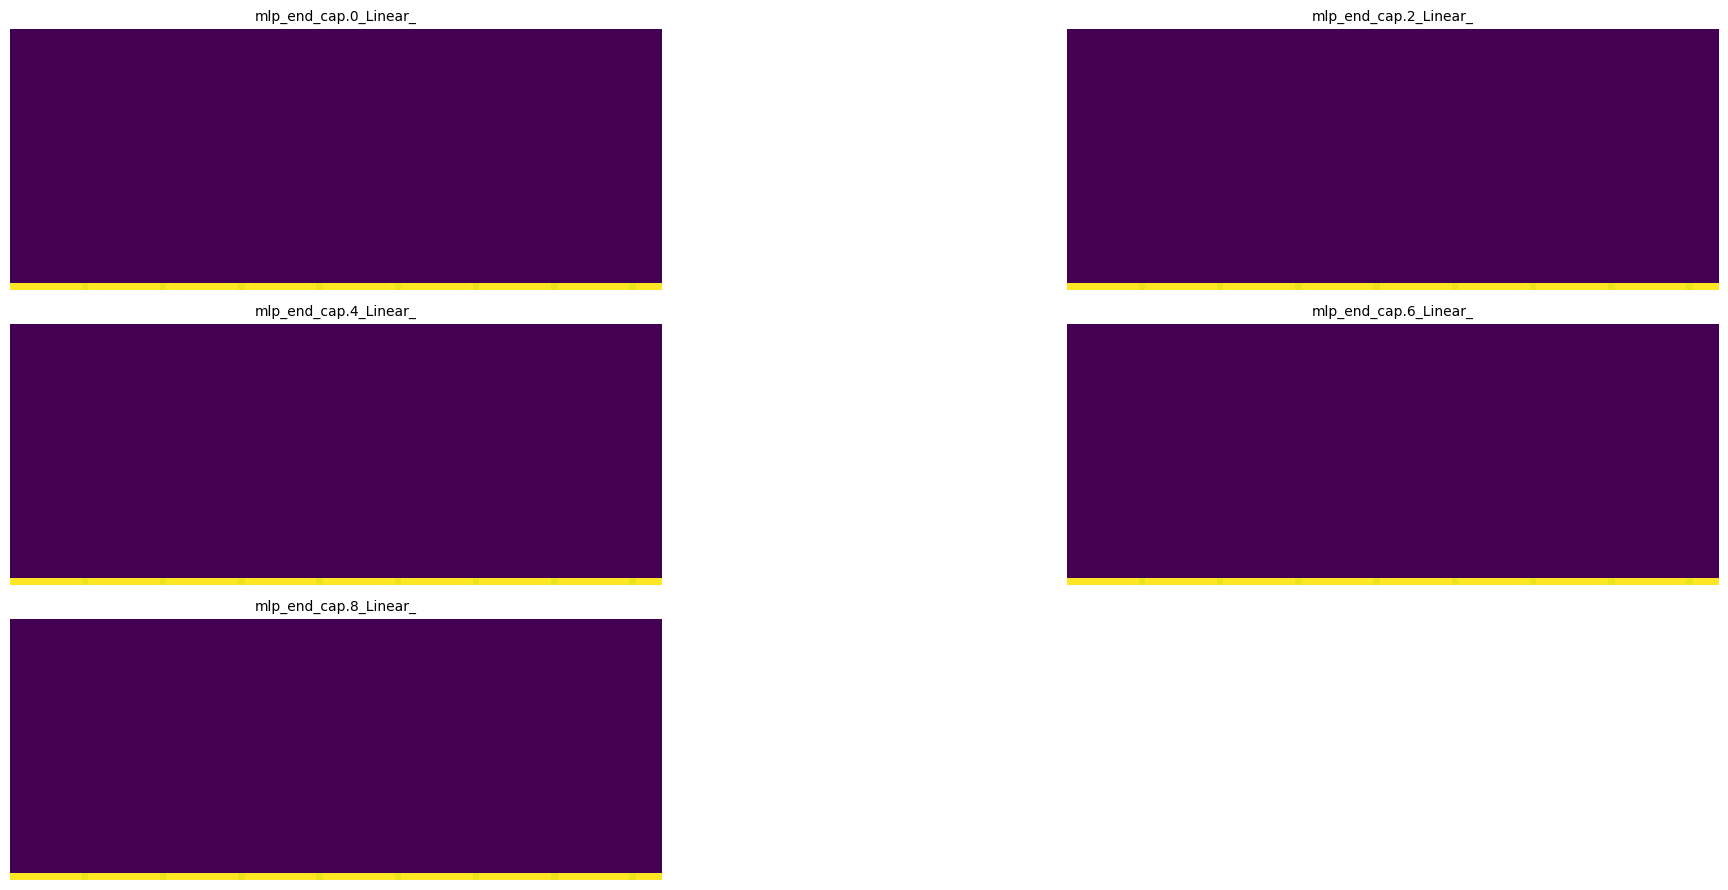

In [18]:
histograms = {}
for layer, hist in gradient_stats.histograms.items():
    hist = torch.stack(hist).mT.numpy()
    histograms[layer] = hist
g = (
    sns.FacetGrid(
        data=pd.DataFrame({k: [0] for k in reversed(histograms)}).melt(var_name='layer', value_name='value'),
        # height=10,
        aspect=4,
        col='layer',
        col_wrap=2,
        # col='value',
    )
    .set_titles('{col_name}')
)
max_evals = 200
for (_, col, hue), _ in g.facet_data():
    ax = g.axes[col]
    ax.set_axis_off()
    layer = g.col_names[col]
    im_out = ax.imshow(np.log1p(histograms[layer][:, :max_evals]), cmap='viridis', origin='lower', aspect='equal')#, vmin=-v_absmax, vmax=v_absmax)
g.tight_layout()

In [19]:
dead = {}
for layer, hist in histograms.items():
    dead[layer] = hist[:1].sum(0) / hist.sum(0)

In [20]:
(
    alt.Chart(pl.DataFrame(dead).with_columns(step=pl.int_range(pl.len())).unpivot(index='step', variable_name='layer'))
    .mark_line()
    .encode(x='step', y='value', color='layer')
)

alt.Chart(...)